In [ ]:
%pip install eyepop==3.12.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 19.1 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 49.0.0
    Uninstalling cryptography-49.0.0:
      Successfully uninstalled cryptography-49.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 26.3.0 requires cryptography<50,>=49.0.0, but you have cryptography 46.0.7 which is incompatible.


In [ ]:
import getpass

EYEPOP_ACCOUNT_ID=input("Enter your Account UUID: ")
EYEPOP_API_KEY=getpass.getpass('Enter your API KEY: ')


Enter your Account UUID: a5184defa8e847248f589d35080efbfa
Enter your API KEY: ··········


In [ ]:
NAMESPACE_PREFIX="datasciencealliance-org" # Add your namespace-prefix here

### Define Ability

In [ ]:
from eyepop import EyePopSdk
from eyepop.data.data_types import InferRuntimeConfig, VlmAbilityGroupCreate, VlmAbilityCreate, TransformInto
from eyepop.worker.worker_types import CropForward, InferenceComponent, Pop
import json


EMOTION_ENGAGEMENT_PROMPT = """
Analyze the cropped Zoom audience participant image and assign exactly one label from the following list:

['engaged', 'confused', 'distressed', 'neutral_uncertain']

This task is based only on visible facial expression, head pose, gaze direction, and body language in the cropped image. Do not identify the person. Do not infer identity, age, gender, ethnicity, or any personal attributes. Classify only the apparent visual state shown in the image.

Choose 'engaged' when the participant appears visually attentive, focused, or actively participating in the meeting. This includes looking toward the screen or camera, upright posture, leaning slightly forward, focused eyes, serious concentration, smiling, nodding, speaking, raising a hand, taking notes while attending to the screen, or otherwise appearing attentive. A participant can still be engaged even if they are not smiling.

Choose 'confused' only when the participant shows clear visual cues of confusion or uncertainty. This includes furrowed brows, puzzled facial expression, tilted head, squinting at the screen, visibly questioning expression, raised eyebrow with uncertainty, or a hand near the face while looking puzzled. Do not choose this label for normal concentration or a serious focused face.

Choose 'distressed' only when the participant shows clear visible cues of distress or discomfort. This includes crying, visibly upset facial expression, hands covering the face, strong frown, worried or overwhelmed expression, panic-like expression, or body language that appears clearly troubled. Do not choose this label for mild tiredness, neutral expression, poor lighting, or normal concentration.

Choose 'neutral_uncertain' when the participant appears neutral, expressionless, tired, distracted, partially visible, blurry, looking away, camera-off, too small to read, occluded, poorly lit, or when there is not enough visual evidence to confidently choose engaged, confused, or distressed. Do not choose 'neutral_uncertain' for a participant who appears focused and attentive toward the screen, even if their expression is serious or not smiling.

If the participant is looking toward the screen with a focused or attentive posture, prefer 'engaged' over 'neutral_uncertain'. If the participant is unreadable, looking away, blurry, occluded, or visually ambiguous, choose 'neutral_uncertain'.

Return only the single best-fitting label.
"""


ability_prototypes = [
    VlmAbilityCreate(
        name=f"{NAMESPACE_PREFIX}.image-classify.emotion-engagement-detection",
        description="Classify apparent engagement state from cropped Zoom audience participant images",
        worker_release="qwen3-instruct",
        text_prompt=EMOTION_ENGAGEMENT_PROMPT,
        transform_into=TransformInto(),
        config=InferRuntimeConfig(
            max_new_tokens=10,
            image_size=640
        ),
        is_public=False
    )
]

### Create Ability

In [ ]:
with EyePopSdk.dataEndpoint(api_key=EYEPOP_API_KEY, account_id=EYEPOP_ACCOUNT_ID) as endpoint:
    for ability_prototype in ability_prototypes:
        ability_group = endpoint.create_vlm_ability_group(VlmAbilityGroupCreate(
            name=ability_prototype.name,
            description=ability_prototype.description,
            default_alias_name=ability_prototype.name,
        ))
        ability = endpoint.create_vlm_ability(
            create=ability_prototype,
            vlm_ability_group_uuid=ability_group.uuid,
        )
        ability = endpoint.publish_vlm_ability(
            vlm_ability_uuid=ability.uuid,
            alias_name=ability_prototype.name,
        )
        ability = endpoint.add_vlm_ability_alias(
            vlm_ability_uuid=ability.uuid,
            alias_name=ability_prototype.name,
            tag_name="latest"
        )
        print(f"created ability {ability.uuid} with alias entries {ability.alias_entries}")

created ability 06a42e35bde27b5a800043abe1f2b75d with alias entries [AbilityAliasEntry(alias='datasciencealliance-org.image-classify.emotion-engagement-detection', tag='1.0.2'), AbilityAliasEntry(alias='datasciencealliance-org.image-classify.emotion-engagement-detection', tag='latest')]


### Evalulate with Person Detection Crop Forward

Processed second 0: {'timestamp': 0, 'engaged': 3, 'confused': 1, 'distressed': 0, 'neutral_uncertain': 2, 'total_people': 6, 'engaged_percent': 50.0, 'confused_percent': 16.666666666666664, 'distressed_percent': 0.0, 'neutral_uncertain_percent': 33.33333333333333}
Processed second 1: {'timestamp': 1, 'engaged': 3, 'confused': 1, 'distressed': 0, 'neutral_uncertain': 2, 'total_people': 6, 'engaged_percent': 50.0, 'confused_percent': 16.666666666666664, 'distressed_percent': 0.0, 'neutral_uncertain_percent': 33.33333333333333}
Processed second 2: {'timestamp': 2, 'engaged': 4, 'confused': 1, 'distressed': 0, 'neutral_uncertain': 1, 'total_people': 6, 'engaged_percent': 66.66666666666666, 'confused_percent': 16.666666666666664, 'distressed_percent': 0.0, 'neutral_uncertain_percent': 16.666666666666664}
Processed second 3: {'timestamp': 3, 'engaged': 3, 'confused': 1, 'distressed': 0, 'neutral_uncertain': 2, 'total_people': 6, 'engaged_percent': 50.0, 'confused_percent': 16.66666666666666

,timestamp,engaged,confused,distressed,neutral_uncertain,total_people,engaged_percent,confused_percent,distressed_percent,neutral_uncertain_percent
0,0,3,1,0,2,6,50.000000,16.666667,0.000000,33.333333
1,1,3,1,0,2,6,50.000000,16.666667,0.000000,33.333333
2,2,4,1,0,1,6,66.666667,16.666667,0.000000,16.666667
3,3,3,1,0,2,6,50.000000,16.666667,0.000000,33.333333
4,4,3,1,1,1,6,50.000000,16.666667,16.666667,16.666667
5,5,3,3,0,0,6,50.000000,50.000000,0.000000,0.000000
6,6,1,4,0,1,6,16.666667,66.666667,0.000000,16.666667
7,7,2,3,0,1,6,33.333333,50.000000,0.000000,16.666667
8,8,2,1,0,3,6,33.333333,16.666667,0.000000,50.000000


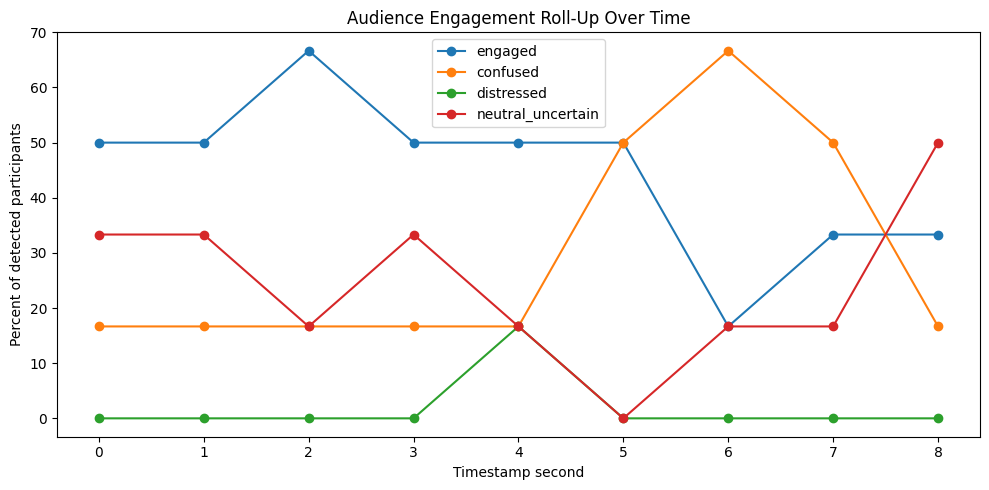

In [ ]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from eyepop import EyePopSdk
from eyepop.worker.worker_types import CropForward, InferenceComponent, Pop


EMOTION_LABELS = ["engaged", "confused", "distressed", "neutral_uncertain"]
EXPECTED_PEOPLE = 6  # Your generated Zoom video has 6 participants


def clean_label(value):
    if not isinstance(value, str):
        return None

    value = value.strip().strip('"').strip("'")
    if value in EMOTION_LABELS:
        return value

    return None


def extract_emotion_label(person_obj):
    """
    Extract the emotion label from one detected person object.
    Do NOT recursively search because that double-counts labels.
    """
    for text_item in person_obj.get("texts", []):
        label = clean_label(text_item.get("text"))
        if label:
            return label

    return None


def box_area(obj):
    return max(0, obj.get("width", 0)) * max(0, obj.get("height", 0))


def intersection_area(a, b):
    ax1 = a.get("x", 0)
    ay1 = a.get("y", 0)
    ax2 = ax1 + a.get("width", 0)
    ay2 = ay1 + a.get("height", 0)

    bx1 = b.get("x", 0)
    by1 = b.get("y", 0)
    bx2 = bx1 + b.get("width", 0)
    by2 = by1 + b.get("height", 0)

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    return max(0, ix2 - ix1) * max(0, iy2 - iy1)


def is_duplicate_box(a, b):
    """
    Detect duplicate person boxes.
    This removes cases where the same participant is detected twice.
    """
    inter = intersection_area(a, b)
    area_a = box_area(a)
    area_b = box_area(b)

    if area_a == 0 or area_b == 0:
        return False

    smaller_overlap = inter / min(area_a, area_b)

    return smaller_overlap > 0.75


def dedupe_people(objects):
    """
    Keep one box per person.
    Sort by confidence, then remove duplicate overlapping boxes.
    """
    people = [
        obj for obj in objects
        if obj.get("category") == "person" or obj.get("classLabel") == "person"
    ]

    people = sorted(people, key=lambda x: x.get("confidence", 0), reverse=True)

    kept = []
    for person in people:
        duplicate = any(is_duplicate_box(person, kept_person) for kept_person in kept)
        if not duplicate:
            kept.append(person)

    return kept


def get_seconds(result, frame_index):
    """
    Prefer the seconds field because timestamp is in nanoseconds.
    """
    if isinstance(result.get("seconds"), (int, float)):
        return float(result["seconds"])

    if isinstance(result.get("timestamp"), (int, float)):
        timestamp = float(result["timestamp"])
        if timestamp > 1_000_000:
            return timestamp / 1_000_000_000
        return timestamp

    return float(frame_index)


pop = Pop(components=[
    InferenceComponent(
        ability="eyepop.person:latest",
        categoryName="person",
        confidenceThreshold=0.5,
        forward=CropForward(targets=[
            InferenceComponent(
                ability=f"{NAMESPACE_PREFIX}.image-classify.emotion-engagement-detection:latest"
            )
        ])
    )
])


# Replace this with your actual video path.
input_path = Path("/content/sample_zoom_audience_video.mp4")


rollup_rows = []
raw_results = []
seen_seconds = set()

with EyePopSdk.workerEndpoint(api_key=EYEPOP_API_KEY) as endpoint:
    endpoint.set_pop(pop)

    job = endpoint.upload(input_path)

    frame_index = 0
    while result := job.predict():
        raw_results.append(result)

        seconds = get_seconds(result, frame_index)
        second_bucket = int(seconds)

        # Keep only one analyzed frame per second for the roll-up graph.
        if second_bucket in seen_seconds:
            frame_index += 1
            continue

        seen_seconds.add(second_bucket)

        objects = result.get("objects", [])
        people = dedupe_people(objects)

        # Since this synthetic video has exactly 6 people, keep the top 6 detections.
        people = sorted(people, key=lambda x: x.get("confidence", 0), reverse=True)[:EXPECTED_PEOPLE]

        labels = []
        for person in people:
            label = extract_emotion_label(person)
            if label:
                labels.append(label)

        row = {
            "timestamp": second_bucket,
            "engaged": labels.count("engaged"),
            "confused": labels.count("confused"),
            "distressed": labels.count("distressed"),
            "neutral_uncertain": labels.count("neutral_uncertain"),
        }

        row["total_people"] = sum(row[label] for label in EMOTION_LABELS)

        if row["total_people"] > 0:
            row["engaged_percent"] = row["engaged"] / row["total_people"] * 100
            row["confused_percent"] = row["confused"] / row["total_people"] * 100
            row["distressed_percent"] = row["distressed"] / row["total_people"] * 100
            row["neutral_uncertain_percent"] = row["neutral_uncertain"] / row["total_people"] * 100
        else:
            row["engaged_percent"] = 0
            row["confused_percent"] = 0
            row["distressed_percent"] = 0
            row["neutral_uncertain_percent"] = 0

        rollup_rows.append(row)

        print(f"Processed second {second_bucket}: {row}")

        frame_index += 1


print("=== RAW EYEPOP RESULTS SAMPLE ===")
print(json.dumps(raw_results[:1], indent=2))

print("\n=== ROLL-UP TABLE ===")
df = pd.DataFrame(rollup_rows)
display(df)


if not df.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(df["timestamp"], df["engaged_percent"], marker="o", label="engaged")
    plt.plot(df["timestamp"], df["confused_percent"], marker="o", label="confused")
    plt.plot(df["timestamp"], df["distressed_percent"], marker="o", label="distressed")
    plt.plot(df["timestamp"], df["neutral_uncertain_percent"], marker="o", label="neutral_uncertain")
    plt.xlabel("Timestamp second")
    plt.ylabel("Percent of detected participants")
    plt.title("Audience Engagement Roll-Up Over Time")
    plt.legend()
    plt.xticks(df["timestamp"])
    plt.tight_layout()
    plt.show()